In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sb

In [35]:
d={"study_hours":[2,4,51,6,None,80,8],"marks":[400,45,34,23,21,43,43],"result":[None,1,1,1,0,0,0]}
df=pd.DataFrame(d)
df

,study_hours,marks,result
0,2.0,400,NaN
1,4.0,45,1.0
2,51.0,34,1.0
3,6.0,23,1.0
4,NaN,21,0.0
5,80.0,43,0.0
6,8.0,43,0.0


In [36]:
df.fillna({"study_hours":df['study_hours'].mean(),'marks':df['marks'].mean(),'result':df['result'].mode()[0]},inplace=True)
df.dropna()
df.drop_duplicates(inplace=True)
df

,study_hours,marks,result
0,2.000000,400,0.0
1,4.000000,45,1.0
2,51.000000,34,1.0
3,6.000000,23,1.0
4,25.166667,21,0.0
5,80.000000,43,0.0
6,8.000000,43,0.0


In [37]:
s=StandardScaler()
df=s.fit_transform(df)
df

array([[-0.84027751,  2.4434171 , -0.8660254 ],
       [-0.76773557, -0.32787066,  1.15470054],
       [ 0.93700011, -0.41374155,  1.15470054],
       [-0.69519363, -0.49961244,  1.15470054],
       [ 0.        , -0.51522533, -0.8660254 ],
       [ 1.98885829, -0.34348355, -0.8660254 ],
       [-0.62265168, -0.34348355, -0.8660254 ]])

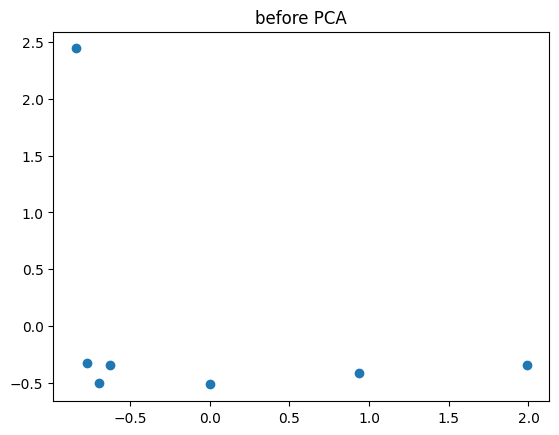

In [38]:
plt.figure()
plt.scatter(df[:,0],df[:,1])
plt.title("before PCA")
plt.show()

In [39]:
pca=PCA()
d=pd.DataFrame(pca.fit_transform(df))
d

,0,1,2
0,2.638037,-0.119879,0.672863
1,-0.503604,-1.332769,0.018936
2,-1.282253,-0.065764,0.856731
3,-0.664298,-1.273559,-0.054748
4,0.041084,0.596520,-0.811131
5,-0.660980,2.066126,0.343173
6,0.432014,0.129325,-1.025824


In [40]:
explained=pca.explained_variance_ratio_
explained

array([0.47254936, 0.38373139, 0.14371925])

In [41]:
cum=np.cumsum(explained)
cum

array([0.47254936, 0.85628075, 1.        ])

In [42]:
n_comp=np.argmax(cum>=0.95)+1
print(n_comp)

3


In [49]:
pcas=PCA(n_components=n_comp)
dr=pcas.fit_transform(df)
t=pd.DataFrame(dr)
t


,0,1,2
0,2.638037,-0.119879,0.672863
1,-0.503604,-1.332769,0.018936
2,-1.282253,-0.065764,0.856731
3,-0.664298,-1.273559,-0.054748
4,0.041084,0.596520,-0.811131
5,-0.660980,2.066126,0.343173
6,0.432014,0.129325,-1.025824


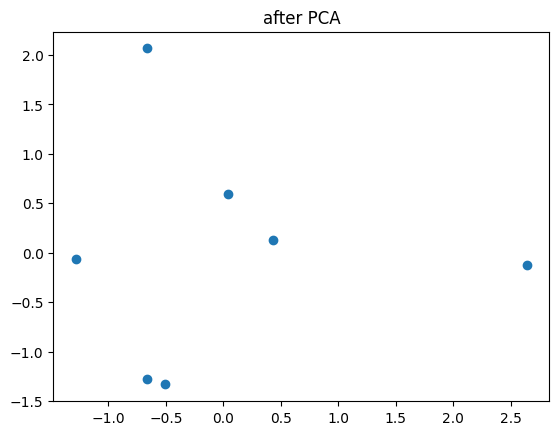

In [50]:
plt.figure()
plt.scatter(dr[:,0],dr[:,1])
plt.title("after PCA")
plt.show()